# 05 — Model Comparison
Loads results from all model notebooks

In [1]:
import numpy as np, os, matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import importlib.util
spec = importlib.util.spec_from_file_location("cfg", "00_config.py")
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)
for a in dir(cfg):
    if not a.startswith('_'): globals()[a] = getattr(cfg, a)

subjects = np.load(CKPT['subjects'], allow_pickle=True).tolist()

METHODS = [
    ('trad_lda',      'Traditional LDA', '#888780'),
    ('shrinkage_lda', 'Shrinkage LDA',   '#D4883E'),
    ('cs_svm',        'Cost-Sens. SVM',  '#E8590C'),
    ('xdawn_lda',     'xDAWN + LDA',     '#2196F3'),
]

results = {}
for key, name, _ in METHODS:
    path = result_path(key)
    if os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        results[key] = {'scores':d['per_subject_scores'], 'yt':d['y_true'], 'yp':d['y_pred'],
                        'time':float(d['elapsed'])}
        print(f"  ✓ {name:<20} {np.mean(d['per_subject_scores']):.3f}±{np.std(d['per_subject_scores']):.3f}")
    else:
        print(f"  ✗ {name:<20} (missing)")

  ✓ Traditional LDA      0.733±0.110
  ✓ Shrinkage LDA        0.754±0.097
  ✓ Cost-Sens. SVM       0.791±0.090
  ✓ xDAWN + LDA          0.816±0.132


In [2]:
# per-subject table
active = [(k,n,c) for k,n,c in METHODS if k in results]
print(f"\n{'Sub':<8}", end="")
for _,n,_ in active: print(f" {n[:10]:>11}", end="")
print()
for si,sub in enumerate(subjects):
    print(f"{sub:<8}", end="")
    for k,_,_ in active: print(f" {results[k]['scores'][si]:>11.3f}", end="")
    print()
print("-"*60)
print(f"{'MEAN':<8}", end="")
for k,_,_ in active: print(f" {np.mean(results[k]['scores']):>11.3f}", end="")
print()


Sub       Traditiona  Shrinkage   Cost-Sens.  xDAWN + LD
sub-010        0.890       0.917       0.858       0.892
sub-011        0.562       0.608       0.655       0.655
sub-012        0.607       0.605       0.732       0.798
sub-013        0.798       0.805       0.862       0.893
sub-014        0.753       0.813       0.837       0.925
sub-015        0.907       0.862       0.887       0.992
sub-016        0.772       0.785       0.910       0.942
sub-019        0.617       0.688       0.653       0.692
sub-020        0.697       0.723       0.795       0.568
sub-021        0.727       0.732       0.722       0.808
------------------------------------------------------------
MEAN           0.733       0.754       0.791       0.816


In [3]:
# ranking
print("\nRanking:")
ranked = sorted(active, key=lambda x: np.mean(results[x[0]]['scores']), reverse=True)
for i,(k,n,_) in enumerate(ranked,1):
    s = results[k]['scores']
    print(f"  {i}. {n:<20} {np.mean(s):.3f}±{np.std(s):.3f}")


Ranking:
  1. xDAWN + LDA          0.816±0.132
  2. Cost-Sens. SVM       0.791±0.090
  3. Shrinkage LDA        0.754±0.097
  4. Traditional LDA      0.733±0.110


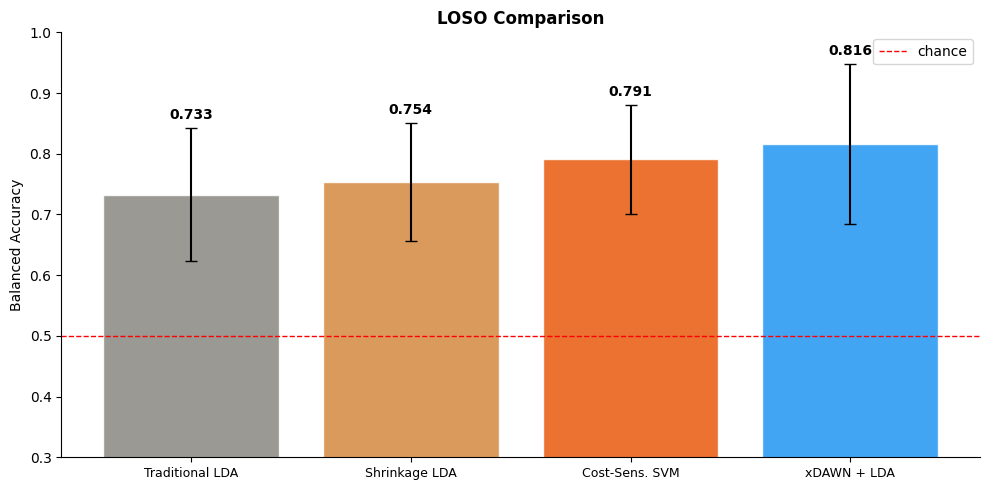

In [4]:
# bar chart
names, means, stds, colors = [], [], [], []
for k,n,clr in METHODS:
    if k in results:
        names.append(n); means.append(np.mean(results[k]['scores']))
        stds.append(np.std(results[k]['scores'])); colors.append(clr)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(names))
ax.bar(x, means, yerr=stds, capsize=4, color=colors, alpha=.85, edgecolor='white')
ax.axhline(0.5, color='red', ls='--', lw=1, label='chance')
for i,(m,s) in enumerate(zip(means,stds)):
    ax.text(i, m+s+0.015, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Balanced Accuracy'); ax.set_title('LOSO Comparison', fontweight='bold')
ax.set_ylim(0.3,1.0); ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

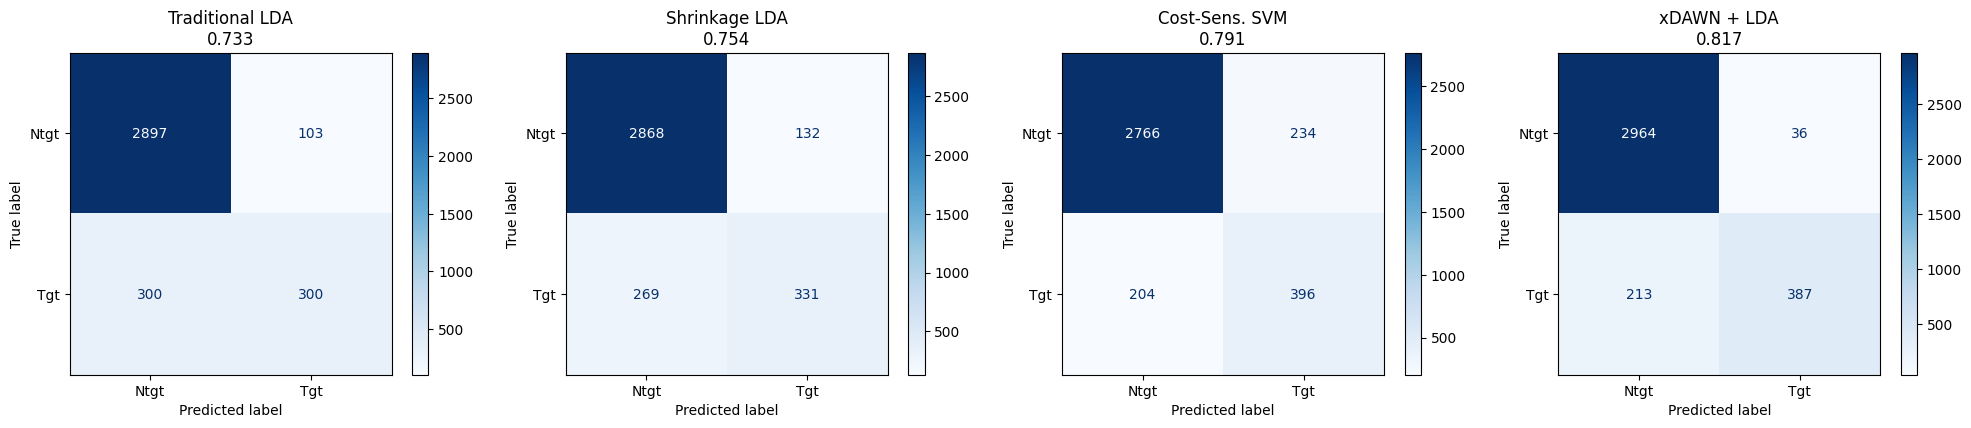

In [5]:
# confusion matrices
fig, axes = plt.subplots(1, len(active), figsize=(5*len(active), 4))
if len(active)==1: axes=[axes]
for ax,(k,n,_) in zip(axes, active):
    yt,yp = results[k]['yt'], results[k]['yp']
    ba = balanced_accuracy_score(yt,yp)
    cm = confusion_matrix(yt,yp)
    ConfusionMatrixDisplay(cm, display_labels=['Ntgt','Tgt']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'{n}\n{ba:.3f}')
plt.tight_layout(); plt.show()

In [6]:
# statistical comparison vs best
if len(active)>=2:
    ranked = sorted(active, key=lambda x: np.mean(results[x[0]]['scores']), reverse=True)
    best_k, best_n, _ = ranked[0]
    print(f"Wilcoxon: {best_n} vs others")
    for k,n,_ in ranked[1:]:
        d = np.mean(results[best_k]['scores']) - np.mean(results[k]['scores'])
        try:
            w,p = stats.wilcoxon(results[best_k]['scores'], results[k]['scores'])
            sig = '**' if p<0.01 else '*' if p<0.05 else 'ns'
        except: w,p,sig = 0,1,'?'
        print(f"  vs {n:<20} Δ={d:+.3f} p={p:.4f} {sig}")

Wilcoxon: xDAWN + LDA vs others
  vs Cost-Sens. SVM       Δ=+0.025 p=0.1211 ns
  vs Shrinkage LDA        Δ=+0.063 p=0.0840 ns
  vs Traditional LDA      Δ=+0.084 p=0.0371 *
